In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score ,recall_score ,f1_score,confusion_matrix, mean_squared_error
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [12]:
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [13]:
df.tail(10)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99990,Male,39.0,0,0,No Info,27.32,6.1,100,0
99991,Male,22.0,0,0,current,29.65,6.0,80,0
99992,Female,26.0,0,0,never,34.34,6.5,160,0
99993,Female,40.0,0,0,never,40.69,3.5,155,0
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [21]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [16]:
df.shape

df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [38]:
df.dtypes

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

In [23]:
calculezero = (df['diabetes'] == 0).sum()
calculeone = (df['diabetes'] == 1).sum()

print(f"0': {calculezero}")
print(f"1': {calculeone}")

#grannd desequilibre entre les 0 et 1   dans le dataset  on doit le regler (class impalance )  


0': 91500
1': 8500


In [24]:
df = df.drop_duplicates()

In [25]:
df.shape

(96146, 9)

In [26]:
df.duplicated().sum()

0

In [27]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [28]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [29]:
df = df[df['age'] >= 7]


In [30]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,89115.000000,89115.000000,89115.000000,89115.000000,89115.000000,89115.000000,89115.000000
mean,44.851821,0.083712,0.043999,28.016222,5.542170,138.652000,0.095046
std,20.403602,0.276957,0.205095,6.427652,1.080259,41.352822,0.293280
min,7.000000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,28.000000,0.000000,0.000000,24.400000,4.800000,100.000000,0.000000
50%,45.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,61.000000,0.000000,0.000000,30.350000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [31]:
df.head(5)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [32]:
categorical_feautres = ['gender','smoking_history']
categorical_feautres


['gender', 'smoking_history']

In [33]:
df['gender'].unique()


array(['Female', 'Male', 'Other'], dtype=object)

In [34]:
df['gender'].value_counts()


gender
Female    52730
Male      36367
Other        18
Name: count, dtype: int64

In [35]:
df = df[df['gender'] != 'Other']


In [37]:
df['gender'].value_counts()

gender
Female    52730
Male      36367
Name: count, dtype: int64

In [39]:
df['smoking_history'].value_counts()

smoking_history
never          33613
No Info        26757
former          9299
current         9180
not current     6254
ever            3994
Name: count, dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89097 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               89097 non-null  object 
 1   age                  89097 non-null  float64
 2   hypertension         89097 non-null  int64  
 3   heart_disease        89097 non-null  int64  
 4   smoking_history      89097 non-null  object 
 5   bmi                  89097 non-null  float64
 6   HbA1c_level          89097 non-null  float64
 7   blood_glucose_level  89097 non-null  int64  
 8   diabetes             89097 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.8+ MB


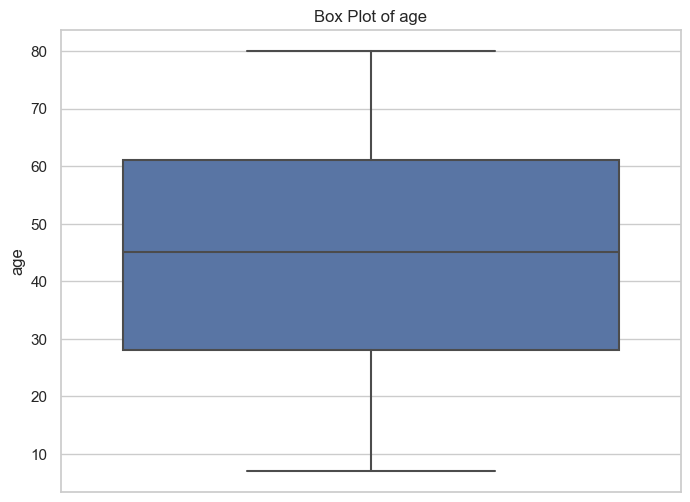

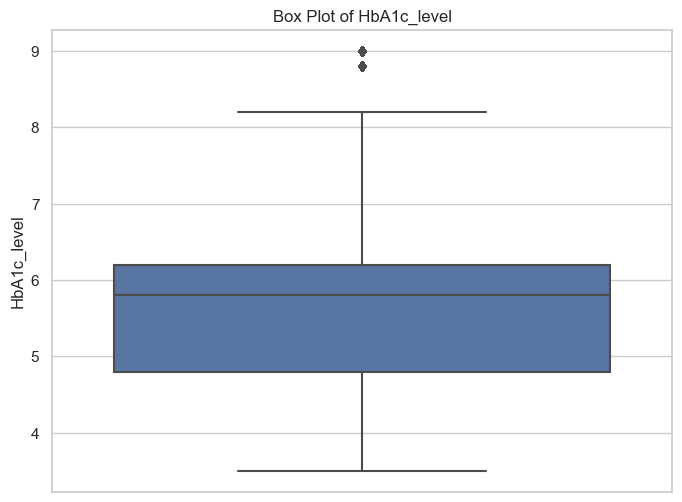

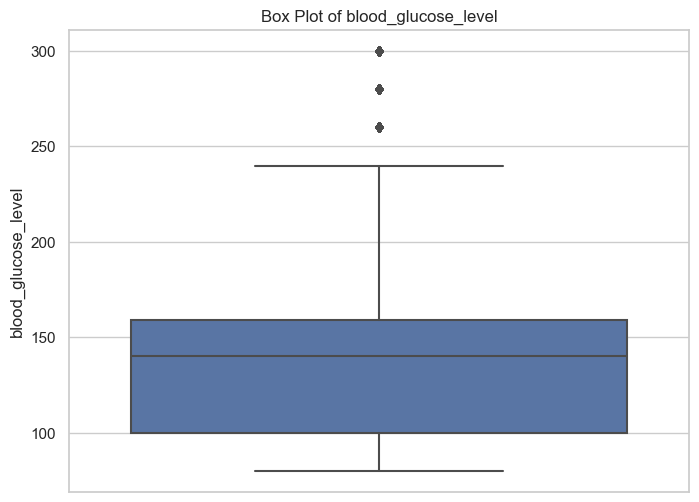

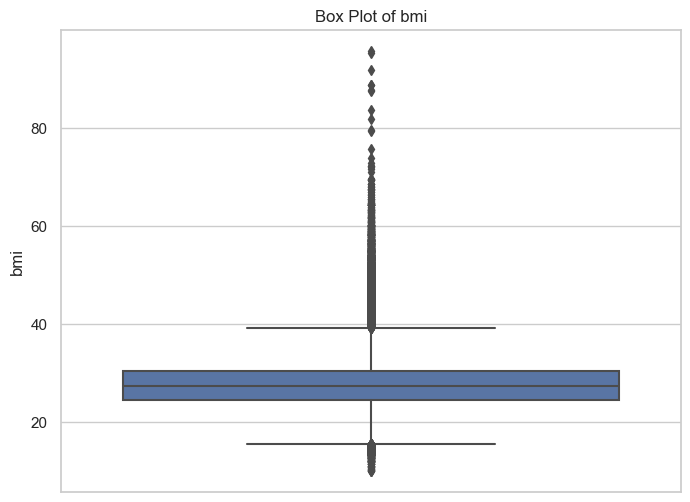

In [86]:
features = ['age', 'HbA1c_level', 'blood_glucose_level', 'bmi']
for feature in features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=feature, data=df)
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
    plt.show()

In [90]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_count = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)].shape[0]

print(f'Number of outliers in bmi: {outliers_count}')


Number of outliers in bmi: 5968


In [91]:
df.shape

(89097, 7)

ENCODAGE DES COLONNES POUR QUE LES ALGORITHMES PUISSE COMPRENDRE




In [41]:
columns_to_encode = ['gender','smoking_history']

In [42]:
ohe= OneHotEncoder(sparse_output = False).set_output(transform='pandas')

In [43]:
ohe_trans = ohe.fit_transform(df[['gender','smoking_history']]).astype(int)

In [44]:
ohe_trans

,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,1,0,0,0,0,0,1,0
1,1,0,1,0,0,0,0,0
2,0,1,0,0,0,0,1,0
3,1,0,0,1,0,0,0,0
4,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...
99993,1,0,0,0,0,0,1,0
99994,1,0,1,0,0,0,0,0
99997,0,1,0,0,0,1,0,0
99998,1,0,0,0,0,0,1,0


In [45]:
df['gender'].unique()


array(['Female', 'Male'], dtype=object)

In [56]:
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [46]:
df = df.drop(['gender', 'smoking_history'], axis=1)

In [47]:
df

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,80.0,0,1,25.19,6.6,140,0
1,54.0,0,0,27.32,6.6,80,0
2,28.0,0,0,27.32,5.7,158,0
3,36.0,0,0,23.45,5.0,155,0
4,76.0,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...
99993,40.0,0,0,40.69,3.5,155,0
99994,36.0,0,0,24.60,4.8,145,0
99997,66.0,0,0,27.83,5.7,155,0
99998,24.0,0,0,35.42,4.0,100,0


In [55]:

finaldata = pd.concat([df, ohe_trans], axis=1, ignore_index=False)
finaldata


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,1,0,1,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99993,40.0,0,0,40.69,3.5,155,0,1,0,0,0,0,0,1,0
99994,36.0,0,0,24.60,4.8,145,0,1,0,1,0,0,0,0,0
99997,66.0,0,0,27.83,5.7,155,0,0,1,0,0,0,1,0,0
99998,24.0,0,0,35.42,4.0,100,0,1,0,0,0,0,0,1,0


In [59]:
scaler = MinMaxScaler()
finaldata[numeric_columns] = scaler.fit_transform(finaldata[numeric_columns])

In [61]:
finaldata.head()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,1.000000,0.0,1.0,0.177171,0.563636,0.272727,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.643836,0.0,0.0,0.202031,0.563636,0.000000,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.287671,0.0,0.0,0.202031,0.400000,0.354545,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.397260,0.0,0.0,0.156863,0.272727,0.340909,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.945205,1.0,1.0,0.118231,0.236364,0.340909,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


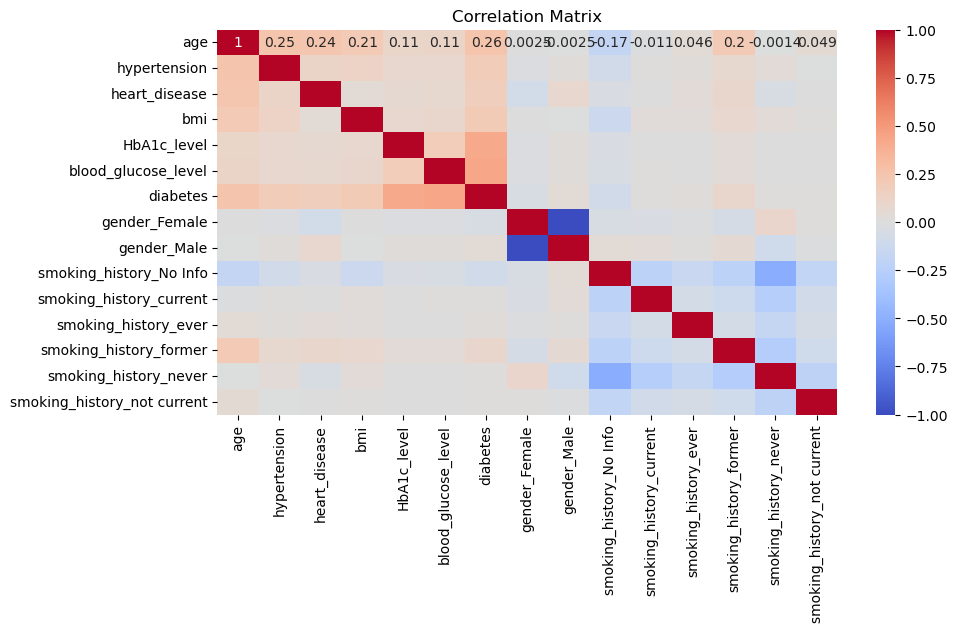

In [84]:
correlation_matrix = finaldata.corr()


plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [83]:
correlation = finaldata.corr()
correlation

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
age,1.000000,0.250005,0.241255,0.209404,0.107664,0.112749,0.256566,0.002466,-0.002466,-0.174605,-0.011217,0.045979,0.203543,-0.001424,0.048510
hypertension,0.250005,1.000000,0.115907,0.129921,0.081674,0.084245,0.190215,-0.019542,0.019542,-0.092849,0.008447,0.016564,0.074009,0.031737,-0.005653
heart_disease,0.241255,0.115907,1.000000,0.044150,0.068558,0.070597,0.166647,-0.085120,0.085120,-0.032413,0.000901,0.036025,0.088909,-0.043266,0.003593
bmi,0.209404,0.129921,0.044150,1.000000,0.082189,0.088827,0.201747,0.006028,-0.006028,-0.132672,0.023525,0.025496,0.085905,0.037674,0.015124
HbA1c_level,0.107664,0.081674,0.068558,0.082189,1.000000,0.181005,0.417869,-0.023355,0.023355,-0.037875,0.002937,0.007173,0.035258,0.004705,0.007532
blood_glucose_level,0.112749,0.084245,0.070597,0.088827,0.181005,1.000000,0.433814,-0.021100,0.021100,-0.041631,0.008886,0.003398,0.038074,0.005299,0.005754
diabetes,0.256566,0.190215,0.166647,0.201747,0.417869,0.433814,1.000000,-0.044517,0.044517,-0.092216,0.009479,0.016886,0.088362,0.010783,0.014299
gender_Female,0.002466,-0.019542,-0.085120,0.006028,-0.023355,-0.021100,-0.044517,1.000000,-1.000000,-0.043117,-0.032298,-0.014209,-0.056795,0.098039,0.009271
gender_Male,-0.002466,0.019542,0.085120,-0.006028,0.023355,0.021100,0.044517,-1.000000,1.000000,0.043117,0.032298,0.014209,0.056795,-0.098039,-0.009271
smoking_history_No Info,-0.174605,-0.092849,-0.032413,-0.132672,-0.037875,-0.041631,-0.092216,-0.043117,0.043117,1.000000,-0.222043,-0.141928,-0.223644,-0.509924,-0.180006


CREATION DE MODELE ML

In [62]:
X = finaldata.drop(columns=['diabetes'])
Y = finaldata['diabetes']

In [65]:
from imblearn.over_sampling import RandomOverSampler

# Create an instance of RandomOverSampler
ros = RandomOverSampler()
# Resample the dataset
X_resampled, y_resampled = ros.fit_resample(X,Y)
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [69]:

print(y_resampled.value_counts())


diabetes
0.0    80627
1.0    80627
Name: count, dtype: int64


In [73]:
model1 = LogisticRegression()
model1.fit(X_resampled,y_resampled)
y_pred = model1.predict(X_resampled)
print("Classification Report:\n", classification_report(y_resampled, y_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.88      0.88     80627
         1.0       0.88      0.87      0.88     80627

    accuracy                           0.88    161254
   macro avg       0.88      0.88      0.88    161254
weighted avg       0.88      0.88      0.88    161254



In [74]:
#tester sans utiliser oversampling
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [75]:
test = LogisticRegression()
test.fit(X_train,Y_train)
testpred = test.predict(X_test)
print("Classification Report:\n", classification_report(Y_test, testpred))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.99      0.98     16164
         1.0       0.88      0.61      0.72      1656

    accuracy                           0.96     17820
   macro avg       0.92      0.80      0.85     17820
weighted avg       0.95      0.96      0.95     17820



In [ ]:
fianldata.to_csv('filename.csv', index=False)